# 04 Tongue Clustering Workflow

This notebook shows the saved Tongue clustering outputs and one concise interpretation path.

Full workflow context: [Tongue Clustering and Analysis](../workflows/tongue-clustering-analysis.md)

Artifacts read here: cluster summary CSVs, centroid JSON, crop-curve stats, and CDL summaries.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

CLUSTER_DIR = Path("/nas/swim/examples/tongue/data/clustering")
summary = pd.read_csv(CLUSTER_DIR / "tongue_cluster_summary.csv")

# k=8 is the working analysis (full stats, crop curves, CDL cross-tabs)
BEST_K = 8
BEST_K

8

In [2]:
summary.sort_values("silhouette", ascending=False)

,k,silhouette,inertia,min_cluster_size,max_cluster_size,best
0,6,0.089201,7.701760e+06,5664,11279,True
1,8,0.082517,7.289414e+06,4258,9881,False
2,10,0.071467,7.009117e+06,3113,7256,False
3,12,0.066766,6.789572e+06,2667,6568,False


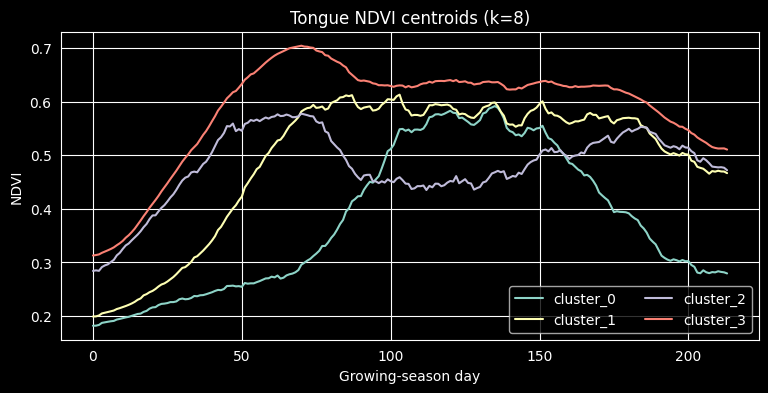

In [3]:
with open(CLUSTER_DIR / f"tongue_ndvi_centroids_k{BEST_K}.json") as f:
    centroids = json.load(f)

fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(111)
for cluster_name, values in list(centroids.items())[:4]:
    ax.plot(values, label=cluster_name)
ax.set_title(f"Tongue NDVI centroids (k={BEST_K})")
ax.set_xlabel("Growing-season day")
ax.set_ylabel("NDVI")
ax.legend(ncol=2)
plt.show()

In [4]:
stats_path = CLUSTER_DIR / f"cluster_stats_k{BEST_K}.csv"
stats = pd.read_csv(stats_path)
stats

,cluster,n_field_years,n_unique_fields,mean_ndvi,greenup_doy,peak_ndvi,peak_doy,senescence_doy,season_length
0,0,4258,1108,0.377313,163,0.591899,226,292.0,129.0
1,1,7124,1586,0.492443,124,0.613174,194,NaN,NaN
2,2,8100,1594,0.481016,97,0.577769,161,NaN,NaN
3,3,9695,1558,0.586471,91,0.704525,161,NaN,NaN
4,4,9881,1730,0.504697,96,0.701304,168,NaN,NaN
5,5,5629,1351,0.371914,129,0.623786,176,278.0,149.0
6,6,5312,1359,0.434842,91,0.661174,151,NaN,NaN
7,7,4817,1337,0.594313,91,0.702890,150,NaN,NaN


In [5]:
cdl_summary_path = CLUSTER_DIR / f"cdl_cluster_summary_k{BEST_K}.csv"
pd.read_csv(cdl_summary_path)

,cluster,n_field_years,top1_crop,top1_pct,top2_crop,top2_pct,top3_crop,top3_pct
0,0,2189,Alfalfa,38.3,Corn,24.6,Grassland/Pasture,18.5
1,1,3484,Alfalfa,47.5,Grassland/Pasture,20.0,Other Hay,16.2
2,2,4226,Alfalfa,44.8,Grassland/Pasture,22.2,Other Hay,19.3
3,3,2722,Alfalfa,41.5,Other Hay,17.6,Grassland/Pasture,17.2
4,4,4089,Grassland/Pasture,29.0,Alfalfa,28.1,Other Hay,22.1
5,5,3451,Grassland/Pasture,33.6,Alfalfa,30.2,Other Hay,16.2
6,6,2526,Grassland/Pasture,30.2,Alfalfa,30.0,Other Hay,26.4
7,7,1520,Alfalfa,38.3,Grassland/Pasture,22.9,Other Hay,18.7
